# RNN vs LSTM (Keras) — Sentiment Analysis (IMDB)

**Goal:** Train and compare a **SimpleRNN** and an **LSTM** model on the IMDB sentiment dataset.

- Task type: **Binary sequence classification**
- Output: probability of **positive** review (1) vs **negative** (0)


## Objectives
1. Load IMDB dataset from Keras.
2. Pad sequences to a fixed length.
3. Build & train a **SimpleRNN** model.
4. Build & train an **LSTM** model.
5. Compare results (test metrics + confusion matrices).
6. Decode a few reviews and inspect predictions.


In [27]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)


In [28]:
vocab_size = 10000   # keep top N most frequent words
max_len = 200        # fixed sequence length after padding

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print("Train:", len(x_train), " Test:", len(x_test))
print("Example token ids:", x_train[0][:20], " label:", y_train[0])


Train: 25000  Test: 25000
Example token ids: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]  label: 1


## Step 1 — Padding

In [29]:
# TODO: Pad sequences to length max_len
# Use keras.preprocessing.sequence.pad_sequences
# padding='pre' and truncating='pre' are common choices

x_train_pad = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len, padding='pre', truncating='pre')
x_test_pad = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len, padding='pre', truncating='pre')


print("X train example (padded):", x_train_pad[0], " label:", y_train[0])
print('-'*50)
print("X test example (padded):", x_test_pad[0], " label:", y_test[0])

# TODO: print shapes (should be (25000, max_len) for IMDB)
print(x_train_pad.shape, x_test_pad.shape)


X train example (padded): [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113 

## Step 2 — SimpleRNN Model

In [30]:
embed_dim = 64

def build_rnn_model():
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        # TODO: add Embedding(input_dim=vocab_size, output_dim=embed_dim)
        # TODO: add SimpleRNN(units=64)
        # TODO: add Dense(1, activation='sigmoid')
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.SimpleRNN(units=64),
        layers.Dense(1, activation='sigmoid')
    ])
    # TODO: compile with optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

# TODO: train 3-5 epochs, validation_split=0.2, batch_size=64
# history_rnn = rnn_model.fit(...)
history_rnn = rnn_model.fit(x_train_pad, y_train, epochs=5, validation_split=0.2, batch_size=64)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6509 - loss: 0.6034 - val_accuracy: 0.8090 - val_loss: 0.4326
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8530 - loss: 0.3433 - val_accuracy: 0.8256 - val_loss: 0.3833
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8978 - loss: 0.2531 - val_accuracy: 0.8334 - val_loss: 0.4665
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9430 - loss: 0.1549 - val_accuracy: 0.8140 - val_loss: 0.5584
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9549 - loss: 0.1196 - val_accuracy: 0.6768 - val_loss: 0.7658


## Step 3 — Plot Curves (RNN)

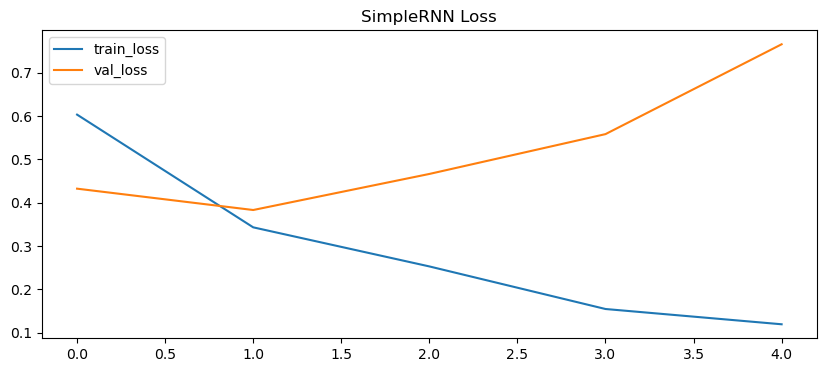

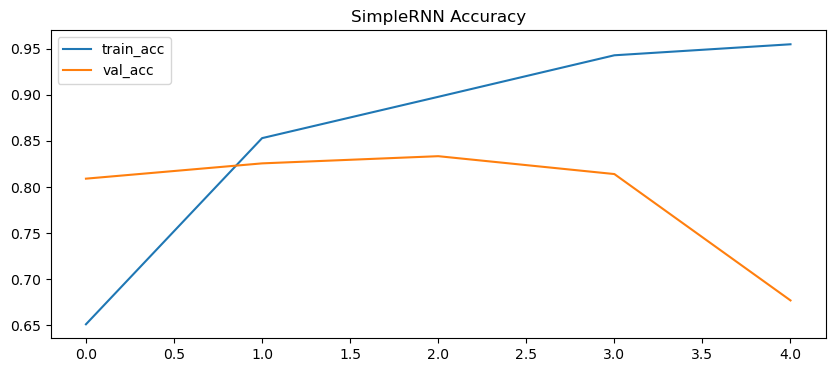

In [42]:
def plot_history(history, title_prefix="Model"):
    # Loss
    plt.figure(figsize=(10,4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure(figsize=(10,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.show()

# TODO: call plot_history(history_rnn, "SimpleRNN")
plot_history(history_rnn, "SimpleRNN")


## Step 4 — LSTM Model

In [32]:
def build_lstm_model():
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        # TODO: add Embedding(input_dim=vocab_size, output_dim=embed_dim)
        # TODO: add LSTM(units=64)
        # TODO: add Dense(1, activation='sigmoid')
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.LSTM(units=64),
        layers.Dense(1, activation='sigmoid')
    ])
    # TODO: compile with optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

# TODO: train 3-5 epochs, validation_split=0.2, batch_size=64
# history_lstm = lstm_model.fit(...)
history_lstm = lstm_model.fit(x_train_pad, y_train, epochs=5, validation_split=0.2, batch_size=64)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7905 - loss: 0.4403 - val_accuracy: 0.8638 - val_loss: 0.3167
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9017 - loss: 0.2563 - val_accuracy: 0.8644 - val_loss: 0.3403
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9169 - loss: 0.2166 - val_accuracy: 0.8694 - val_loss: 0.3365
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9350 - loss: 0.1789 - val_accuracy: 0.8688 - val_loss: 0.4021
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9426 - loss: 0.1576 - val_accuracy: 0.8542 - val_loss: 0.4179


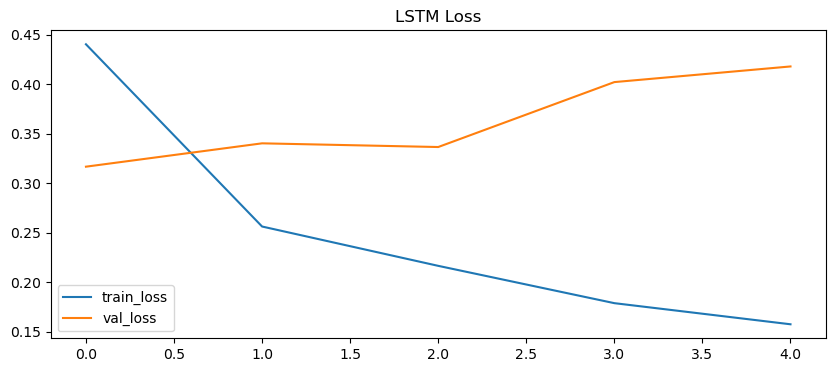

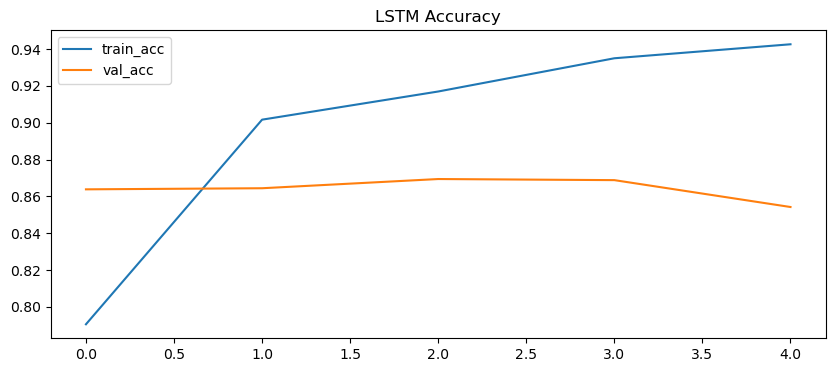

In [38]:
plot_history(history_lstm, "LSTM")

## Step 5 — Evaluate on Test

In [33]:
# TODO: evaluate both models on test set
# rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test_pad, y_test, verbose=0)
# lstm_test_loss, lstm_test_acc = lstm_model.evaluate(x_test_pad, y_test, verbose=0)

rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test_pad, y_test, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(x_test_pad, y_test, verbose=0)
# print results
print(f"RNN - Loss: {rnn_test_loss}, Accuracy: {rnn_test_acc}")
print(f"LSTM - Loss: {lstm_test_loss}, Accuracy: {lstm_test_acc}")

RNN - Loss: 0.753866970539093, Accuracy: 0.680840015411377
LSTM - Loss: 0.4342106580734253, Accuracy: 0.8459200263023376


## Step 6 — Confusion Matrices

In [34]:
def get_preds_binary(model, x):
    probs = model.predict(x, verbose=0).squeeze()
    preds = (probs >= 0.5).astype(np.int32)
    return probs, preds

# TODO: compute confusion matrices for RNN and LSTM using tf.math.confusion_matrix
# rnn_probs, rnn_preds = get_preds_binary(rnn_model, x_test_pad)
# lstm_probs, lstm_preds = get_preds_binary(lstm_model, x_test_pad)
rnn_probs, rnn_preds = get_preds_binary(rnn_model, x_test_pad)
lstm_probs, lstm_preds = get_preds_binary(lstm_model, x_test_pad)

# print("x_test_pad :", x_test_pad[:1])
# print("RNN Predictions:", rnn_preds[:20])
# print("RNN Probabilities:", rnn_probs[:20])
# print("LSTM Predictions:", lstm_preds[:20])
# print("LSTM Probabilities:", lstm_probs[:20])

# cm_rnn = tf.math.confusion_matrix(y_test, rnn_preds, num_classes=2).numpy()
# cm_lstm = tf.math.confusion_matrix(y_test, lstm_preds, num_classes=2).numpy()
cm_rnn = tf.math.confusion_matrix(y_test, rnn_preds, num_classes=2).numpy()
cm_lstm = tf.math.confusion_matrix(y_test, lstm_preds, num_classes=2).numpy()

# print(cm_rnn)
# print(cm_lstm)
print("RNN Confusion Matrix:\n", cm_rnn)
print("LSTM Confusion Matrix:\n", cm_lstm)


RNN Confusion Matrix:
 [[7885 4615]
 [3364 9136]]
LSTM Confusion Matrix:
 [[11122  1378]
 [ 2474 10026]]


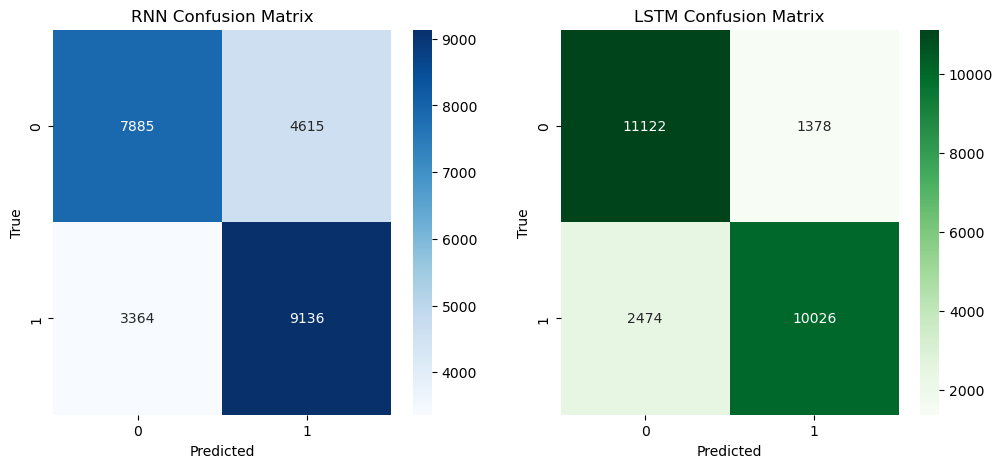

In [35]:
#visualize the confusion matrices
import seaborn as sns
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues')
plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.subplot(1,2,2)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Step 7 — Decode & Inspect Predictions

In [41]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

print("Word index example:", list(word_index.items())[:10])

def decode_review(tokens):
    return " ".join([reverse_word_index.get(i, "<UNK>") for i in tokens])

# TODO:
# Pick 3 indices from test set, decode, and show:
# - first 80 words
# - true label
# - predicted prob from RNN and LSTM

sample_indices = np.random.choice(len(x_test), size=3, replace=False)
for idx in sample_indices:
    print(f"Review {idx}:")
    print("Decoded review:", decode_review(x_test[idx][:80]))
    print("True label:", y_test[idx])
    rnn_model.predict(x_test_pad[idx:idx+1], verbose=0).squeeze()
    lstm_model.predict(x_test_pad[idx:idx+1], verbose=0).squeeze()
    
    print(f"RNN predicted probability: {rnn_model.predict(x_test_pad[idx:idx+1], verbose=0).squeeze()}")
    print(f"LSTM predicted probability: {lstm_model.predict(x_test_pad[idx:idx+1], verbose=0).squeeze()}")


Word index example: [('fawn', 34701), ('tsukino', 52006), ('nunnery', 52007), ('sonja', 16816), ('vani', 63951), ('woods', 1408), ('spiders', 16115), ('hanging', 2345), ('woody', 2289), ('trawling', 52008)]
Review 3130:
Decoded review: <START> what a trip down memory lane br br do not look for great acting believable plot lines or anything resembling a quality movie br br this is pure <UNK> at it's finest outrageous outfits dialog <UNK> of women and the <UNK> cops you can imagine br br this vanity piece by the godfather of rap <UNK> ray moore who left us for good last week is the standard by which all <UNK> is <UNK> br br you not only
True label: 1
RNN predicted probability: 0.1175428256392479
LSTM predicted probability: 0.9717219471931458
Review 2449:
Decoded review: <START> this really is a film of two <UNK> the first <UNK> the lives and friendship of two boys one a <UNK> and the other a down <UNK> in late 70s afghanistan before the invasion by the <UNK> works extremely well the youn

## Deliverables
1. Correct padding shapes.
2. Trained SimpleRNN + training curves.
3. Trained LSTM + training curves.
4. Test metrics comparison.
5. Confusion matrix for each model.
6. 3 decoded examples with predictions + short conclusion:
   - Which model performed better and why?
   - Any signs of overfitting? How did you know?
